In [29]:

import pickle
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:

def compute_mean_interval(data):
    """
    Compute the mean, 95% confidence interval, and margin of error for a Pandas Series.

    Parameters:
    data (pd.Series): A Pandas Series containing data.

    Returns:
    tuple: A tuple containing the mean, 95% confidence interval, and margin of error.
          mean (float): The mean (average) of the data.
          interval (tuple): A tuple representing the confidence interval.
            It consists of two values: the lower bound and the upper bound.
          margin_of_error (float): The margin of error for the mean, used to compute the confidence interval.
    """
    
    # Compute mean and size of our serie ignoring nan values
    mean = np.nanmean(data)
    data_size = np.count_nonzero(~np.isnan(data))
    
    # Set significance level
    alpha = 0.05
    
    # Compute the standard error of the mean
    sem = np.nanstd(data) / np.sqrt(data_size)
    
    # Calculate the critical value for a two-tailed test
    critical_value = stats.t.ppf(1 - alpha / 2, df= data_size - 1)
    
    # Compute the margin of error
    margin_of_error = critical_value * sem
    
    # Calculate the confidence interval
    interval = (mean - margin_of_error, mean + margin_of_error)
    
    return mean, interval, margin_of_error   

In [31]:
with open('../model_performance/logistic_regression_performance.pkl', 'rb') as file:
    logistic_regression_data = pickle.load(file)

In [32]:
with open('../model_performance/ridge_regression_performance.pkl', 'rb') as file:
    ridge_regression_data = pickle.load(file)

In [33]:
f1_scores = []
accuraries = []
models = ["logistic \n regression","penalized \n logistic\n  regression","linear\n regression","ridge \n regression"]
best_models_indices = []

In [34]:
f1_scores.append(logistic_regression_data[4][7][:,1])
f1_scores.append(logistic_regression_data[13][7][:,1])
f1_scores.append(ridge_regression_data[0][7][:,1])
f1_scores.append(ridge_regression_data[7][7][:,1])

accuraries.append(logistic_regression_data[4][7][:,2])
accuraries.append(logistic_regression_data[13][7][:,2])
accuraries.append(ridge_regression_data[0][7][:,2])
accuraries.append(ridge_regression_data[7][7][:,2])



In [35]:
def plot_box(data1, data2, labels, title1, title2, y1label,y2label):
    """
    Create a combined plot with two vertical box plots.

    Args:
    data1 (list of lists): Data for the first set of plots.
    data2 (list of lists): Data for the second set of plots.
    labels (list): Labels for the data.
    title1 (str): Title for the left box plot.
    title2 (str): Title for the right box plot.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    """
    plt.figure(figsize=(12, 6))  # Adjust the figure size as needed

    # Create the left box plot
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, select the 1st subplot
    sns.boxplot(data=data1)
    plt.xticks(np.arange(len(labels)), labels)
    plt.title(title1)
    plt.xlabel("Models")
    plt.ylabel(y1label)

    # Create the right box plot
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, select the 2nd subplot
    sns.boxplot(data=data2)
    plt.xticks(np.arange(len(labels)), labels)
    plt.title(title2)
    plt.xlabel(y2label)
    plt.ylabel("Models")

    plt.tight_layout()  # Helps avoid subplot labels overlapping
    plt.show()

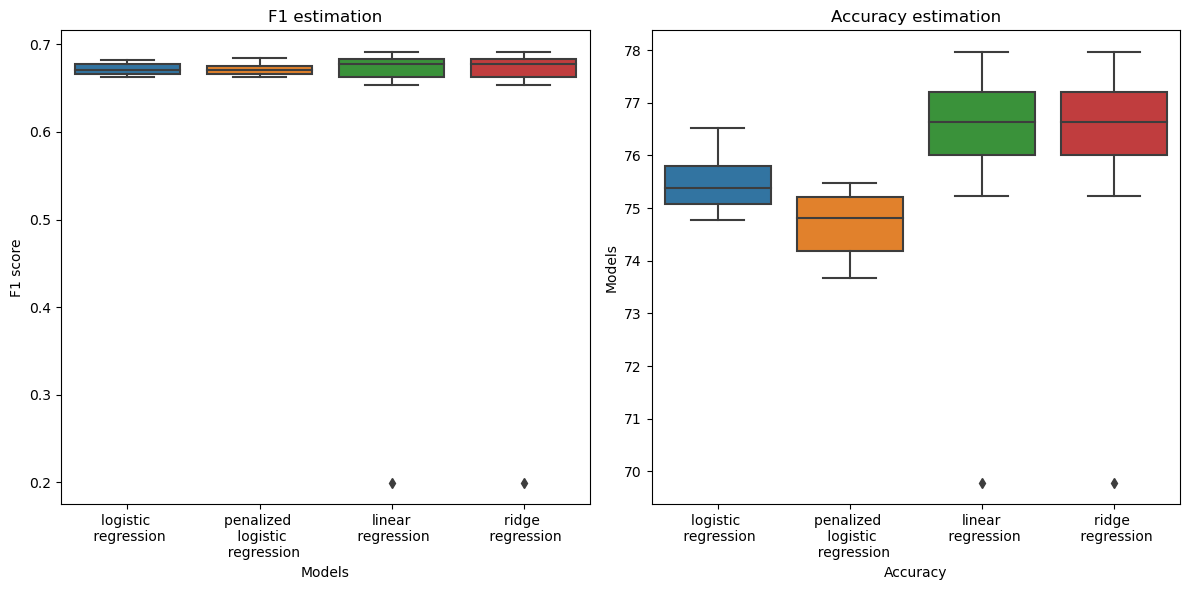

In [36]:
plot_box(f1_scores,accuraries,models,"F1 estimation","Accuracy estimation","F1 score","Accuracy")